In [16]:
import numpy as np
import gymnasium as gym
import importlib
import envs

import learners
import analysis
importlib.reload(analysis)
importlib.reload(learners)
from learners import *
from analysis import *

def get_exp_scheduler(alpha, n_ep_decay, min_val=0.005): return lambda t: max(alpha * 0.5**(t/n_ep_decay), min_val)

params = Params(
    model_name="CliffSlipperyLow",
    n_runs=3,
    n_episodes=10_000,
    save_skip=50,
    lr_decay=None,
    seed=123,
    
    N=64,
    alpha=0.5,
    gamma=0.99,
    epsilon=0.0,
    kappa=0.0,
    
    nA=None,
    nS=None,
    shape=None,
)
rng = np.random.default_rng(params.seed)
tau = (np.arange(params.N) + 0.5) / params.N
env = gym.make(
    params.model_name,
    p_random=0.9,
)
params = params._replace(nA=int(env.action_space.n))
params = params._replace(nS=int(env.observation_space.n))
params = params._replace(shape=env.unwrapped.shape)
s_init, _ = env.reset()

save_to = "results/results/random09_"+params.model_name

In [13]:
policy, V_pi = PolicyIteration(env, params.gamma)
explorer = EpsilonGreedy(rng)

returns = MonteCarlo(env, policy, params.gamma, total_episodes=10_000)
tau_returns = np.quantile(np.sort(returns), tau)

100%|██████████| 10000/10000 [00:10<00:00, 934.15it/s]


In [17]:
scheduler = get_exp_scheduler(params.alpha, 2000, min_val=0.00025)

table0 = QR(params, policy).train(env, explorer, scheduler)
# table1 = QR(params._replace(kappa=1.0), policy).train(env, explorer, scheduler)
# qtable = Qlearner(params, policy).train(env, explorer, scheduler)

100%|██████████| 30000/30000 [03:26<00:00, 145.13it/s, run=3, t=1e+4]


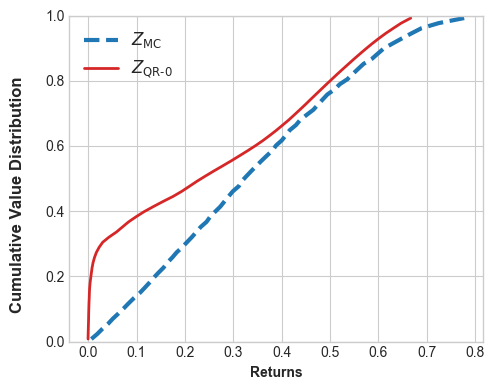

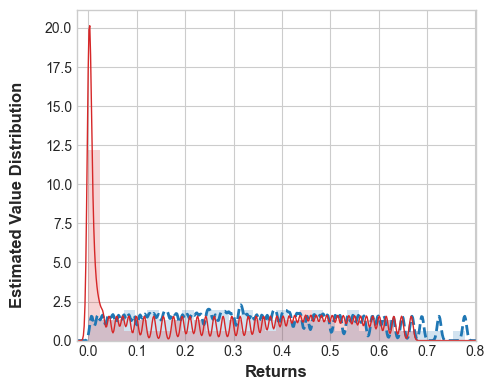

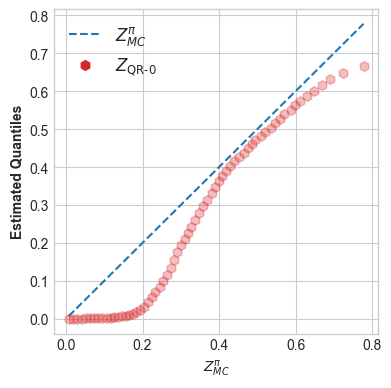

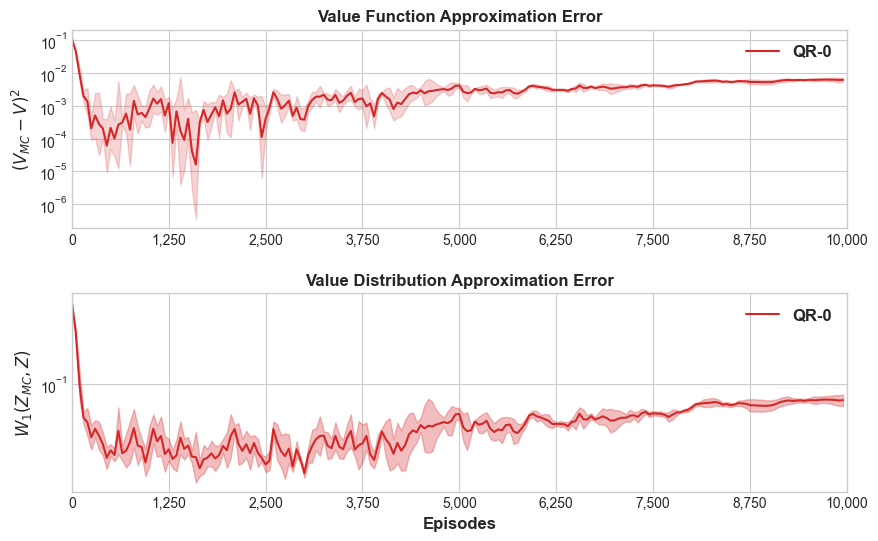

In [18]:
def get_q(table): return table[:,:,s_init,policy[s_init].argmax()]#.max(2)
def get_best(table): return get_q(table)[:,-1].mean(0)

plot_objs = [
    (get_best(table0), r"$Z_{\text{QR-0}}$"),
]
plot_qs = [
    (get_q(table0), "QR-0"),
]
LOW_BANDWIDTH = 0.004
bw = LOW_BANDWIDTH#*100

plot_cdf(plot_objs, tau_returns, tau, linewidths=(3,2), save_to=save_to, returns_name=r"$Z_{\text{MC}}$")
plot_pdf(plot_objs, tau_returns, bandwidth=bw, show_hist=True, linewidth=1.0, N=params.N//2, hist_alpha=0.2, save_to=save_to)
plot_qq(plot_objs, tau_returns, save_to=save_to, alpha=0.3, markersize=7, lims=None)
plot_metrics(plot_qs, tau_returns, save_skip=params.save_skip, save_to=save_to, alphas=[0.2,0.3], true_dist="{MC}")

In [ ]:
tables_mc = np.zeros((params.nS, 1000))
for s in tqdm(range(params.nS)):
    if env.unwrapped._is_terminal.flatten()[s]:
        s_ret = np.zeros(1000)
    else:
        s_ret = MonteCarlo(env, policy, params.gamma, s_init=s, total_episodes=1000, use_tqdm=False)
    tables_mc[s] = np.sort(s_ret)